<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/Nonequilibriumthermodynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Non-equilibrium thermodynamics with NeqSim

**Audience.** Process engineers and advanced students who know equilibrium thermodynamics and want
to quantify irreversibility in transport processes and unit operations.

**Learning objectives.** You will learn to:

1. distinguish local equilibrium properties from non-equilibrium fluxes;
2. calculate entropy generation from heat conduction, diffusion, and pressure loss;
3. build and test an Onsager coefficient matrix for coupled transport;
4. quantify throttling and compressor irreversibility with NeqSim states; and
5. verify positivity, reciprocity, conservation, and expected operating trends.

Pressures are absolute. SI units are used unless a table states otherwise.

In [1]:
import importlib.util
import platform
import subprocess
import sys
from importlib.metadata import version

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim.thermo import PHflash, PSflash, TPflash, fluid

java_result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
)
runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_result.stderr.splitlines()[0],
        ],
    }
)
display(runtime_table)

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21


## 1. Local equilibrium and entropy production

Non-equilibrium thermodynamics assumes each small material element has equilibrium properties such
as temperature, pressure, enthalpy, entropy, viscosity, and diffusivity. Spatial gradients drive
fluxes between elements. For a control volume at steady state,

$$
\dot S_{gen} = \sum_{out}\dot m s - \sum_{in}\dot m s - \sum_k\frac{\dot Q_k}{T_k}
$$

The second law requires $\dot S_{gen}\ge 0$. The corresponding lost work relative to an environment
at temperature $T_0$ is the Gouy-Stodola relation

$$
\dot E_D = T_0 \dot S_{gen}
$$

NeqSim supplies local thermodynamic and transport properties. The flux laws and equipment balances
below turn those properties into entropy-generation rates.

In [2]:
gas_composition = {
    "methane": 0.85,
    "ethane": 0.08,
    "CO2": 0.04,
    "nitrogen": 0.03,
}
base_temperature_k = 320.0
base_pressure_bara = 30.0
environment_temperature_k = 298.15


def create_gas_state(temperature_k, pressure_bara):
    state = fluid("srk")

    for component_name, mole_fraction in gas_composition.items():
        state.addComponent(component_name, mole_fraction)

    state.setMixingRule("classic")
    state.setTemperature(temperature_k, "K")
    state.setPressure(pressure_bara, "bara")
    TPflash(state)
    state.initProperties()
    return state


base_state = create_gas_state(base_temperature_k, base_pressure_bara)
composition_sum = sum(gas_composition.values())
assert abs(composition_sum - 1.0) < 1.0e-12

## 2. Reproducible gas state

The public lean-gas mixture is a teaching case, not an asset assay. SRK with the classic mixing rule
is suitable for this single-phase hydrocarbon-gas screen. Each derived state is flashed before its
properties are read. Enthalpy and entropy reference values may be arbitrary; differences between
same-composition states are physically meaningful.

In [3]:
base_phase = base_state.getPhase("gas")
base_properties = base_phase.getPhysicalProperties()
base_property_table = pd.DataFrame(
    {
        "Property": [
            "Phase count",
            "Density",
            "Dynamic viscosity",
            "Thermal conductivity",
            "Specific enthalpy",
            "Specific entropy",
        ],
        "Value": [
            base_state.getNumberOfPhases(),
            base_state.getDensity("kg/m3"),
            base_properties.getViscosity(),
            base_properties.getConductivity(),
            base_state.getEnthalpy("J/kg"),
            base_state.getEntropy("J/kgK"),
        ],
        "Unit": ["-", "kg/m³", "Pa s", "W/(m K)", "J/kg", "J/(kg K)"],
    }
)
display(base_property_table)

               Property         Value      Unit
0           Phase count      1.000000         -
1               Density     22.017130     kg/m³
2     Dynamic viscosity      0.000013      Pa s
3  Thermal conductivity      0.037840   W/(m K)
4     Specific enthalpy  65528.889805      J/kg
5      Specific entropy  -1006.619157  J/(kg K)


## 3. Heat conduction between finite-temperature reservoirs

Fourier's law for a planar layer is

$$
\dot Q = k A \frac{T_h-T_c}{L}
$$

For heat flowing from a hot reservoir at $T_h$ to a cold reservoir at $T_c$, the reservoirs generate
entropy at the rate

$$
\dot S_{gen,Q} = \dot Q\left(\frac{1}{T_c}-\frac{1}{T_h}\right)
$$

Here $k$ is thermal conductivity in W/(m K), $A$ is area in m², and $L$ is layer thickness in m.

In [4]:
hot_temperature_k = 350.0
cold_temperature_k = 290.0
wall_area_m2 = 10.0
wall_thickness_m = 0.05
thermal_conductivity_w_m_k = base_properties.getConductivity()
heat_rate_w = thermal_conductivity_w_m_k * wall_area_m2
heat_rate_w *= (hot_temperature_k - cold_temperature_k) / wall_thickness_m
heat_entropy_generation_w_k = heat_rate_w * (
    1.0 / cold_temperature_k - 1.0 / hot_temperature_k
)
heat_exergy_destruction_w = (
    environment_temperature_k * heat_entropy_generation_w_k
)

heat_table = pd.DataFrame(
    {
        "Quantity": ["Heat rate", "Entropy generation", "Exergy destruction"],
        "Value": [
            heat_rate_w,
            heat_entropy_generation_w_k,
            heat_exergy_destruction_w,
        ],
        "Unit": ["W", "W/K", "W"],
    }
)
display(heat_table)

             Quantity       Value Unit
0           Heat rate  454.079315    W
1  Entropy generation    0.268421  W/K
2  Exergy destruction   80.029802    W


### Thermal-resistance sensitivity

Increasing layer thickness reduces heat rate and therefore reduces entropy generation for fixed
reservoir temperatures and area. This statement is specific to the fixed-boundary-temperature
problem; a required-duty design would behave differently.

    Layer thickness [m]  Heat rate [W]  Entropy generation [W/K]
0                  0.01    2270.396577                  1.342106
1                  0.02    1135.198289                  0.671053
2                  0.03     756.798859                  0.447369
3                  0.04     567.599144                  0.335527
4                  0.05     454.079315                  0.268421
5                  0.06     378.399430                  0.223684
6                  0.07     324.342368                  0.191729
7                  0.08     283.799572                  0.167763
8                  0.09     252.266286                  0.149123
9                  0.10     227.039658                  0.134211
10                 0.11     206.399689                  0.122010
11                 0.12     189.199715                  0.111842
12                 0.13     174.645891                  0.103239
13                 0.14     162.171184                  0.095865
14                 0.15  

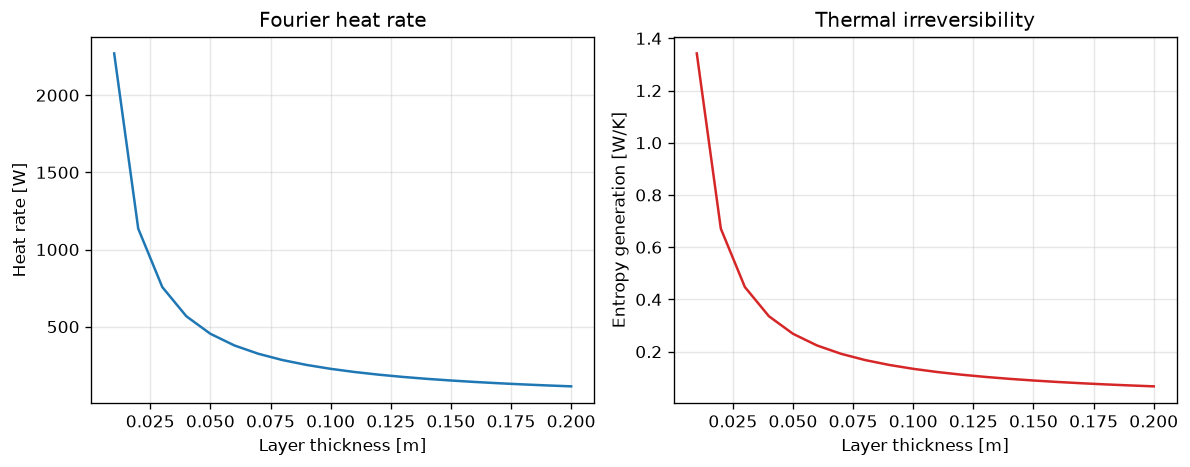

In [5]:
wall_thickness_values_m = np.linspace(0.01, 0.20, 20)
heat_rate_values_w = thermal_conductivity_w_m_k * wall_area_m2
heat_rate_values_w *= (
    hot_temperature_k - cold_temperature_k
) / wall_thickness_values_m
heat_entropy_values_w_k = heat_rate_values_w * (
    1.0 / cold_temperature_k - 1.0 / hot_temperature_k
)

thermal_sensitivity_table = pd.DataFrame(
    {
        "Layer thickness [m]": wall_thickness_values_m,
        "Heat rate [W]": heat_rate_values_w,
        "Entropy generation [W/K]": heat_entropy_values_w_k,
    }
)
display(thermal_sensitivity_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(wall_thickness_values_m, heat_rate_values_w)
axes[0].set_xlabel("Layer thickness [m]")
axes[0].set_ylabel("Heat rate [W]")
axes[0].set_title("Fourier heat rate")
axes[1].plot(wall_thickness_values_m, heat_entropy_values_w_k, color="tab:red")
axes[1].set_xlabel("Layer thickness [m]")
axes[1].set_ylabel("Entropy generation [W/K]")
axes[1].set_title("Thermal irreversibility")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Diffusion and chemical-potential driving force

For an ideal-mixture screening calculation, the chemical potential difference of CO₂ across a film
is $\Delta\mu=RT\ln(x_b/x_i)$. Combining Fick's law with the thermodynamic force gives

$$
J_{CO_2} = D_{CO_2,CH_4} c_t \frac{x_b-x_i}{\delta}
$$

$$
\sigma_D = \frac{J_{CO_2}\Delta\mu}{T\delta}
$$

$\sigma_D$ is volumetric entropy production in W/(m³ K). This simplified binary expression is used
to teach force-flux consistency; a rigorous multicomponent interface requires Maxwell-Stefan
transport and fugacity-based chemical potentials.

In [6]:
base_properties.setDiffusionCoefficientModel("Fuller-Schettler-Giddings")
base_properties.init(base_phase)
co2_methane_diffusivity_m2_s = base_properties.getDiffusionCoefficient(
    "CO2",
    "methane",
)
total_concentration_mol_m3 = (
    base_properties.getDensity() / base_phase.getMolarMass()
)
bulk_co2_fraction = 0.04
interface_co2_fraction = 0.01
diffusion_film_thickness_m = 1.0e-3
gas_constant_j_mol_k = 8.314462618
co2_flux_mol_m2_s = co2_methane_diffusivity_m2_s
co2_flux_mol_m2_s *= total_concentration_mol_m3
co2_flux_mol_m2_s *= (
    bulk_co2_fraction - interface_co2_fraction
) / diffusion_film_thickness_m
chemical_potential_drop_j_mol = gas_constant_j_mol_k * base_temperature_k
chemical_potential_drop_j_mol *= np.log(
    bulk_co2_fraction / interface_co2_fraction
)
diffusion_entropy_generation_w_m3_k = (
    co2_flux_mol_m2_s
    * chemical_potential_drop_j_mol
    / base_temperature_k
    / diffusion_film_thickness_m
)

diffusion_table = pd.DataFrame(
    {
        "Quantity": [
            "CO₂-methane diffusivity",
            "Total molar concentration",
            "CO₂ flux",
            "Chemical-potential drop",
            "Volumetric entropy production",
        ],
        "Value": [
            co2_methane_diffusivity_m2_s,
            total_concentration_mol_m3,
            co2_flux_mol_m2_s,
            chemical_potential_drop_j_mol,
            diffusion_entropy_generation_w_m3_k,
        ],
        "Unit": ["m²/s", "mol/m³", "mol/(m² s)", "J/mol", "W/(m³ K)"],
    }
)
display(diffusion_table)

                        Quantity         Value        Unit
0        CO₂-methane diffusivity  6.789875e-07        m²/s
1      Total molar concentration  1.180989e+03      mol/m³
2                       CO₂ flux  2.405631e-02  mol/(m² s)
3        Chemical-potential drop  3.688414e+03       J/mol
4  Volumetric entropy production  2.772801e+02    W/(m³ K)


### Diffusion-film sensitivity

The prescribed composition difference is held fixed. Both flux and volumetric entropy production
therefore increase as the assumed film becomes thinner. The trend is a model diagnostic, not a
method for choosing film thickness.

In [7]:
diffusion_thickness_values_mm = np.array([0.25, 0.50, 1.00, 2.00, 4.00])
diffusion_thickness_values_m = diffusion_thickness_values_mm / 1000.0
diffusion_flux_values = co2_methane_diffusivity_m2_s
diffusion_flux_values *= total_concentration_mol_m3
diffusion_flux_values *= (
    bulk_co2_fraction - interface_co2_fraction
) / diffusion_thickness_values_m
diffusion_entropy_values = diffusion_flux_values * chemical_potential_drop_j_mol
diffusion_entropy_values /= base_temperature_k * diffusion_thickness_values_m

diffusion_sensitivity_table = pd.DataFrame(
    {
        "Film thickness [mm]": diffusion_thickness_values_mm,
        "CO₂ flux [mol/(m² s)]": diffusion_flux_values,
        "Entropy production [W/(m³ K)]": diffusion_entropy_values,
    }
)
display(diffusion_sensitivity_table)

   Film thickness [mm]  CO₂ flux [mol/(m² s)]  Entropy production [W/(m³ K)]
0                 0.25               0.096225                    4436.480890
1                 0.50               0.048113                    1109.120222
2                 1.00               0.024056                     277.280056
3                 2.00               0.012028                      69.320014
4                 4.00               0.006014                      17.330003


## 5. Coupled fluxes and Onsager reciprocity

Near equilibrium, generalized fluxes are linear in thermodynamic forces:

$$
\mathbf{J}=\mathbf{L}\mathbf{X}, \qquad \sigma=\mathbf{J}^{T}\mathbf{X}
$$

For heat and mass transport without magnetic or rotational symmetry breaking, Onsager reciprocity
requires $L_{12}=L_{21}$. Nonnegative entropy production additionally requires the symmetric matrix
$\mathbf{L}$ to be positive semidefinite. We use scaled forces so the numerical example is easy to
inspect; the matrix is illustrative rather than fitted NeqSim data.

In [8]:
onsager_matrix = np.array(
    [
        [2.0, 0.40],
        [0.40, 1.0],
    ]
)
scaled_forces = np.array([0.80, -0.25])
scaled_fluxes = onsager_matrix @ scaled_forces
onsager_entropy_production = float(scaled_fluxes @ scaled_forces)
onsager_eigenvalues = np.linalg.eigvalsh(onsager_matrix)
reciprocity_residual = onsager_matrix[0, 1] - onsager_matrix[1, 0]

onsager_table = pd.DataFrame(
    {
        "Quantity": [
            "Heat-like flux",
            "Mass-like flux",
            "Scaled entropy production",
            "Minimum matrix eigenvalue",
            "Reciprocity residual",
        ],
        "Value": [
            scaled_fluxes[0],
            scaled_fluxes[1],
            onsager_entropy_production,
            onsager_eigenvalues.min(),
            reciprocity_residual,
        ],
    }
)
display(onsager_table)

                    Quantity     Value
0             Heat-like flux  1.500000
1             Mass-like flux  0.070000
2  Scaled entropy production  1.182500
3  Minimum matrix eigenvalue  0.859688
4       Reciprocity residual  0.000000


### Coupling-strength screen

For a two-by-two symmetric matrix with positive diagonal terms, excessive cross-coupling makes one
eigenvalue negative and violates the second law. The determinant boundary is therefore a useful
parameter-fitting guard.

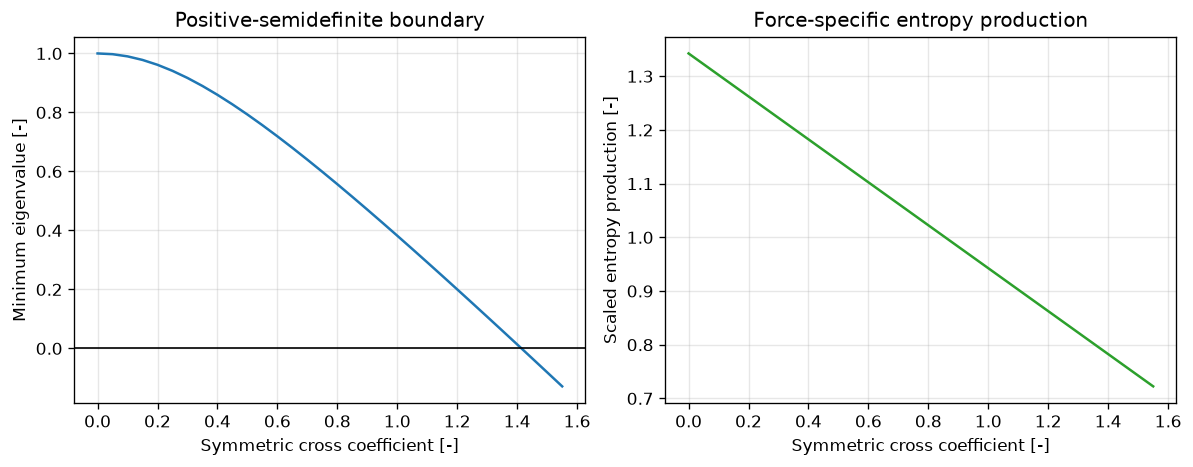

In [9]:
coupling_values = np.linspace(0.0, 1.55, 32)
minimum_eigenvalues = []
coupled_entropy_values = []

for coupling_value in coupling_values:
    trial_matrix = np.array(
        [
            [2.0, coupling_value],
            [coupling_value, 1.0],
        ]
    )
    trial_fluxes = trial_matrix @ scaled_forces
    minimum_eigenvalues.append(np.linalg.eigvalsh(trial_matrix).min())
    coupled_entropy_values.append(float(trial_fluxes @ scaled_forces))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(coupling_values, minimum_eigenvalues)
axes[0].axhline(0.0, color="black", linewidth=1.0)
axes[0].set_xlabel("Symmetric cross coefficient [-]")
axes[0].set_ylabel("Minimum eigenvalue [-]")
axes[0].set_title("Positive-semidefinite boundary")
axes[1].plot(coupling_values, coupled_entropy_values, color="tab:green")
axes[1].set_xlabel("Symmetric cross coefficient [-]")
axes[1].set_ylabel("Scaled entropy production [-]")
axes[1].set_title("Force-specific entropy production")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Viscous dissipation in a gas pipe

Mechanical energy degraded by friction appears as entropy generation. For an isothermal screening
calculation with volumetric flow $\dot V$ and pressure loss $\Delta P$,

$$
\dot S_{gen,f} = \frac{\dot V\Delta P}{T}
$$

We use the Haaland Darcy friction factor. Compressibility, acceleration, elevation, and heat transfer
are neglected, so the result is an engineering cross-check rather than a pipeline simulator.

In [10]:
pipe_length_m = 1000.0
pipe_diameter_m = 0.20
pipe_roughness_m = 1.0e-5
pipe_velocity_m_s = 8.0
gas_density_kg_m3 = base_properties.getDensity()
gas_viscosity_pa_s = base_properties.getViscosity()
pipe_area_m2 = np.pi * pipe_diameter_m**2 / 4.0
volumetric_flow_m3_s = pipe_area_m2 * pipe_velocity_m_s
reynolds_number = (
    gas_density_kg_m3
    * pipe_velocity_m_s
    * pipe_diameter_m
    / gas_viscosity_pa_s
)
relative_roughness = pipe_roughness_m / pipe_diameter_m
haaland_term = (relative_roughness / 3.7) ** 1.11 + 6.9 / reynolds_number
darcy_friction_factor = 1.0 / (-1.8 * np.log10(haaland_term)) ** 2
pressure_drop_pa = darcy_friction_factor * pipe_length_m / pipe_diameter_m
pressure_drop_pa *= gas_density_kg_m3 * pipe_velocity_m_s**2 / 2.0
friction_power_w = volumetric_flow_m3_s * pressure_drop_pa
friction_entropy_generation_w_k = friction_power_w / base_temperature_k

pipe_table = pd.DataFrame(
    {
        "Quantity": [
            "Reynolds number",
            "Darcy friction factor",
            "Pressure drop",
            "Friction power",
            "Entropy generation",
        ],
        "Value": [
            reynolds_number,
            darcy_friction_factor,
            pressure_drop_pa / 1.0e5,
            friction_power_w,
            friction_entropy_generation_w_k,
        ],
        "Unit": ["-", "-", "bar", "W", "W/K"],
    }
)
display(pipe_table)

                Quantity         Value Unit
0        Reynolds number  2.746807e+06    -
1  Darcy friction factor  1.145603e-02    -
2          Pressure drop  4.035662e-01  bar
3         Friction power  1.014273e+04    W
4     Entropy generation  3.169602e+01  W/K


## 7. Isenthalpic throttling

An adiabatic valve has negligible shaft work, so specific enthalpy should remain constant. Entropy
usually increases:

$$
h_{out}=h_{in}, \qquad \dot S_{gen,v}=\dot m(s_{out}-s_{in})
$$

We set $\dot m=1$ kg/s so the numerical entropy-rate value equals the specific entropy rise. NeqSim's
PH flash calculates every outlet state from inlet enthalpy and outlet pressure.

In [11]:
inlet_enthalpy_j_kg = base_state.getEnthalpy("J/kg")
inlet_entropy_j_kg_k = base_state.getEntropy("J/kgK")
valve_outlet_pressures_bara = np.array([25.0, 20.0, 15.0, 10.0, 5.0])
valve_rows = []

for outlet_pressure_bara in valve_outlet_pressures_bara:
    outlet_state = base_state.clone()
    outlet_state.setPressure(outlet_pressure_bara, "bara")
    PHflash(outlet_state, inlet_enthalpy_j_kg, "J/kg")
    outlet_state.initProperties()
    enthalpy_residual_j_kg = (
        outlet_state.getEnthalpy("J/kg") - inlet_enthalpy_j_kg
    )
    entropy_rise_j_kg_k = (
        outlet_state.getEntropy("J/kgK") - inlet_entropy_j_kg_k
    )
    valve_rows.append(
        {
            "Outlet pressure [bara]": outlet_pressure_bara,
            "Outlet temperature [K]": outlet_state.getTemperature("K"),
            "Enthalpy residual [J/kg]": enthalpy_residual_j_kg,
            "Entropy rise [J/(kg K)]": entropy_rise_j_kg_k,
            "Exergy destruction [kW per kg/s]": (
                environment_temperature_k * entropy_rise_j_kg_k / 1000.0
            ),
        }
    )

valve_table = pd.DataFrame(valve_rows)
display(valve_table)

   Outlet pressure [bara]  ...  Exergy destruction [kW per kg/s]
0                    25.0  ...                         23.245690
1                    20.0  ...                         51.881291
2                    15.0  ...                         89.059356
3                    10.0  ...                        141.858770
4                     5.0  ...                        232.869976

[5 rows x 5 columns]


Larger pressure reduction increases entropy generation and lost work in this single-phase range.
The temperature falls because this gas has a positive Joule-Thomson coefficient at the selected
state; that trend is fluid- and state-dependent.

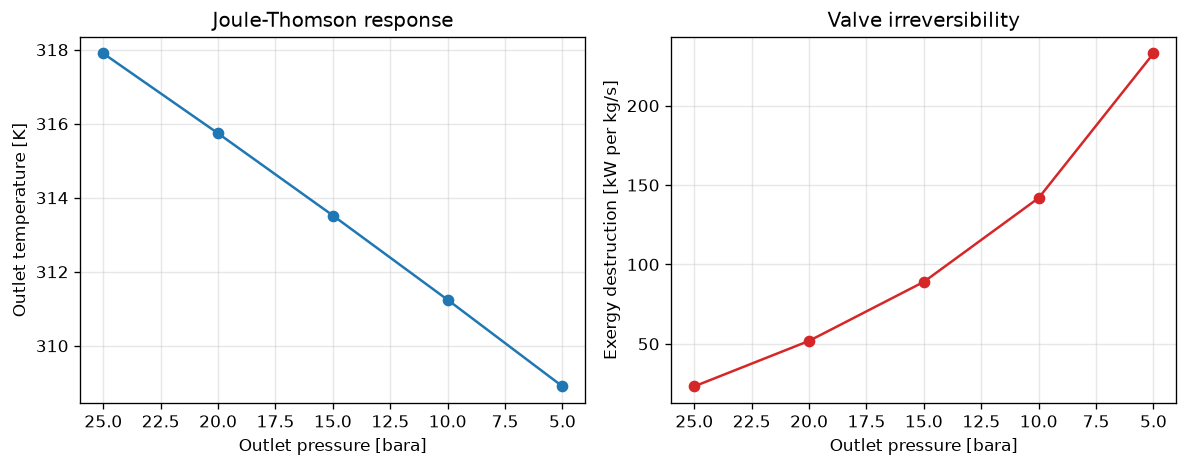

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(
    valve_table["Outlet pressure [bara]"],
    valve_table["Outlet temperature [K]"],
    marker="o",
)
axes[0].set_xlabel("Outlet pressure [bara]")
axes[0].set_ylabel("Outlet temperature [K]")
axes[0].set_title("Joule-Thomson response")
axes[1].plot(
    valve_table["Outlet pressure [bara]"],
    valve_table["Exergy destruction [kW per kg/s]"],
    marker="o",
    color="tab:red",
)
axes[1].set_xlabel("Outlet pressure [bara]")
axes[1].set_ylabel("Exergy destruction [kW per kg/s]")
axes[1].set_title("Valve irreversibility")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.invert_xaxis()

plt.tight_layout()
plt.show()

## 8. Adiabatic compression

An ideal adiabatic compressor is isentropic. With isentropic efficiency $\eta_s$, actual specific
work is

$$
w = \frac{h_{out,s}-h_{in}}{\eta_s}
$$

The actual outlet is recovered with a PH flash. Lower efficiency must increase work, outlet
temperature, entropy generation, and exergy destruction.

In [13]:
compressor_outlet_pressure_bara = 60.0
isentropic_outlet = base_state.clone()
isentropic_outlet.setPressure(compressor_outlet_pressure_bara, "bara")
PSflash(isentropic_outlet, inlet_entropy_j_kg_k, "J/kgK")
isentropic_outlet.initProperties()
isentropic_enthalpy_j_kg = isentropic_outlet.getEnthalpy("J/kg")
isentropic_work_j_kg = isentropic_enthalpy_j_kg - inlet_enthalpy_j_kg
compressor_efficiencies = np.array([0.65, 0.70, 0.75, 0.80, 0.85])
compressor_rows = []

for compressor_efficiency in compressor_efficiencies:
    actual_work_j_kg = isentropic_work_j_kg / compressor_efficiency
    actual_enthalpy_j_kg = inlet_enthalpy_j_kg + actual_work_j_kg
    actual_outlet = base_state.clone()
    actual_outlet.setPressure(compressor_outlet_pressure_bara, "bara")
    PHflash(actual_outlet, actual_enthalpy_j_kg, "J/kg")
    actual_outlet.initProperties()
    entropy_rise_j_kg_k = (
        actual_outlet.getEntropy("J/kgK") - inlet_entropy_j_kg_k
    )
    compressor_rows.append(
        {
            "Isentropic efficiency [-]": compressor_efficiency,
            "Specific work [kJ/kg]": actual_work_j_kg / 1000.0,
            "Outlet temperature [K]": actual_outlet.getTemperature("K"),
            "Entropy rise [J/(kg K)]": entropy_rise_j_kg_k,
            "Exergy destruction [kJ/kg]": (
                environment_temperature_k * entropy_rise_j_kg_k / 1000.0
            ),
        }
    )

compressor_table = pd.DataFrame(compressor_rows)
display(compressor_table)

   Isentropic efficiency [-]  ...  Exergy destruction [kJ/kg]
0                       0.65  ...                   42.791266
1                       0.70  ...                   34.260602
2                       0.75  ...                   26.785743
3                       0.80  ...                   20.181599
4                       0.85  ...                   14.304060

[5 rows x 5 columns]


### Compressor-efficiency interpretation

Entropy generation is zero for the separately calculated isentropic reference within numerical
precision. The actual PH-flashed states quantify how internal dissipation shifts temperature and
work as efficiency changes.

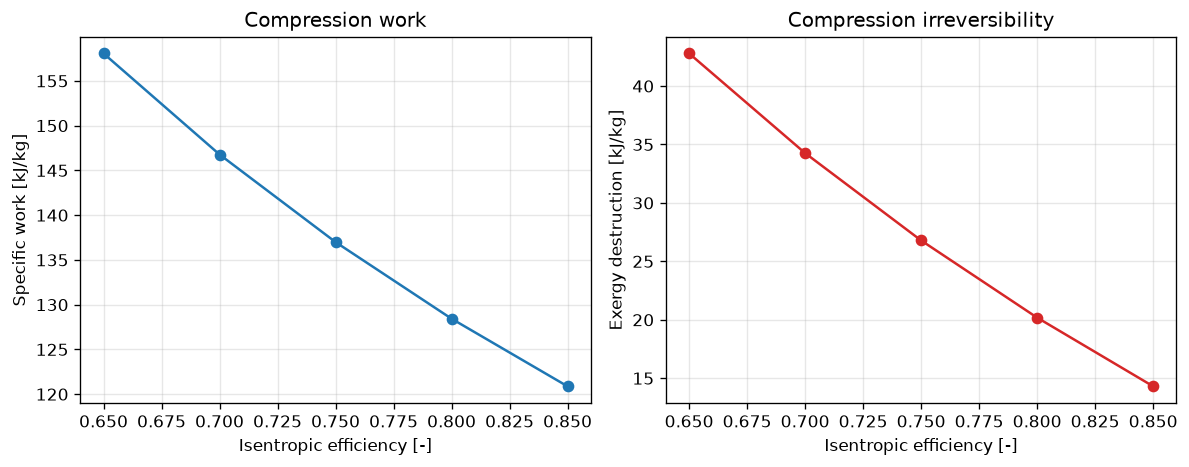

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(
    compressor_table["Isentropic efficiency [-]"],
    compressor_table["Specific work [kJ/kg]"],
    marker="o",
)
axes[0].set_xlabel("Isentropic efficiency [-]")
axes[0].set_ylabel("Specific work [kJ/kg]")
axes[0].set_title("Compression work")
axes[1].plot(
    compressor_table["Isentropic efficiency [-]"],
    compressor_table["Exergy destruction [kJ/kg]"],
    marker="o",
    color="tab:red",
)
axes[1].set_xlabel("Isentropic efficiency [-]")
axes[1].set_ylabel("Exergy destruction [kJ/kg]")
axes[1].set_title("Compression irreversibility")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Validation checks

These assertions test finite properties, phase identity, second-law signs, expected sensitivities,
Onsager reciprocity and matrix admissibility, valve enthalpy closure, isentropic entropy closure, and
compressor efficiency trends. They are regression checks, not experimental validation.

In [15]:
valve_enthalpy_residual_max = valve_table["Enthalpy residual [J/kg]"].abs().max()
isentropic_entropy_residual = (
    isentropic_outlet.getEntropy("J/kgK") - inlet_entropy_j_kg_k
)
engineering_checks = {
    "composition sums to one": abs(composition_sum - 1.0) < 1.0e-12,
    "base state is one gas phase": base_state.getNumberOfPhases() == 1,
    "base density is finite and positive": np.isfinite(gas_density_kg_m3)
    and gas_density_kg_m3 > 0.0,
    "viscosity is finite and positive": np.isfinite(gas_viscosity_pa_s)
    and gas_viscosity_pa_s > 0.0,
    "conductivity is finite and positive": np.isfinite(thermal_conductivity_w_m_k)
    and thermal_conductivity_w_m_k > 0.0,
    "heat flows hot to cold": heat_rate_w > 0.0,
    "heat entropy generation is positive": heat_entropy_generation_w_k > 0.0,
    "thicker wall lowers fixed-boundary heat rate": np.all(
        np.diff(heat_rate_values_w) < 0.0
    ),
    "diffusivity is in gas scale": 1.0e-8 < co2_methane_diffusivity_m2_s < 1.0e-3,
    "diffusion follows its chemical force": co2_flux_mol_m2_s > 0.0,
    "diffusion entropy production is positive": diffusion_entropy_generation_w_m3_k
    > 0.0,
    "thicker diffusion film lowers flux": np.all(np.diff(diffusion_flux_values) < 0.0),
    "Onsager reciprocity closes": abs(reciprocity_residual) < 1.0e-15,
    "Onsager matrix is positive definite": np.all(onsager_eigenvalues > 0.0),
    "Onsager entropy production is positive": onsager_entropy_production > 0.0,
    "pipe calculation is turbulent": reynolds_number > 1.0e4,
    "friction factor is plausible": 0.005 < darcy_friction_factor < 0.1,
    "friction entropy generation is positive": friction_entropy_generation_w_k > 0.0,
    "valve enthalpy closes": valve_enthalpy_residual_max < 1.0e-2,
    "valve entropy rises": np.all(valve_table["Entropy rise [J/(kg K)]"] > 0.0),
    "deeper throttling increases destruction": np.all(
        np.diff(valve_table["Exergy destruction [kW per kg/s]"]) > 0.0
    ),
    "isentropic entropy closes": abs(isentropic_entropy_residual) < 1.0e-8,
    "higher efficiency lowers compressor work": np.all(
        np.diff(compressor_table["Specific work [kJ/kg]"]) < 0.0
    ),
    "higher efficiency lowers compressor destruction": np.all(
        np.diff(compressor_table["Exergy destruction [kJ/kg]"]) < 0.0
    ),
}

failed_checks = [name for name, passed in engineering_checks.items() if not passed]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"
print(f"All {len(engineering_checks)} engineering checks passed.")

All 24 engineering checks passed.


## 10. Summary

Every example obeys the second law. Heat and diffusion generate entropy because their fluxes follow
thermodynamic forces; friction destroys mechanical availability; throttling preserves enthalpy while
raising entropy; and finite compressor efficiency increases both work and lost work. The Onsager
example shows why reciprocity alone is insufficient—the coefficient matrix must also be admissible.

In [16]:
summary_table = pd.DataFrame(
    {
        "Result": [
            "Heat entropy generation",
            "Heat exergy destruction",
            "CO₂-methane diffusivity",
            "Diffusion entropy production",
            "Pipe friction entropy generation",
            "Valve destruction at 5 bara",
            "Compressor destruction at 75% efficiency",
            "Maximum valve enthalpy residual",
        ],
        "Value": [
            heat_entropy_generation_w_k,
            heat_exergy_destruction_w,
            co2_methane_diffusivity_m2_s,
            diffusion_entropy_generation_w_m3_k,
            friction_entropy_generation_w_k,
            valve_table.iloc[-1]["Exergy destruction [kW per kg/s]"],
            compressor_table.iloc[2]["Exergy destruction [kJ/kg]"],
            valve_enthalpy_residual_max,
        ],
        "Unit": ["W/K", "W", "m²/s", "W/(m³ K)", "W/K", "kW", "kJ/kg", "J/kg"],
    }
)
display(summary_table)

                                     Result         Value      Unit
0                   Heat entropy generation  2.684213e-01       W/K
1                   Heat exergy destruction  8.002980e+01         W
2                   CO₂-methane diffusivity  6.789875e-07      m²/s
3              Diffusion entropy production  2.772801e+02  W/(m³ K)
4          Pipe friction entropy generation  3.169602e+01       W/K
5               Valve destruction at 5 bara  2.328700e+02        kW
6  Compressor destruction at 75% efficiency  2.678574e+01     kJ/kg
7           Maximum valve enthalpy residual  4.023296e-05      J/kg


## Limitations and applicability

- Linear Onsager laws apply near equilibrium; the illustrative matrix is not fitted transport data.
- The diffusion example assumes ideal chemical potentials, a binary film, constant properties, and
  prescribed interface composition. Rigorous work should use fugacity gradients and multicomponent
  Maxwell-Stefan transport.
- The conduction and pipe calculations neglect property variation and geometry-specific effects.
- Valve and compressor states are thermodynamically rigorous for the stated SRK model, but project
  work needs a tuned fluid model and verified equipment efficiencies.
- Chemical reactions, interfacial area, transient storage, and coupled heat/mass transfer require a
  dedicated non-equilibrium unit-operation or fluid-mechanics model.

## Exercises

1. Replace the ideal diffusion force with a fugacity-based chemical-potential difference.
2. Fit an Onsager matrix and enforce symmetry plus nonnegative eigenvalues during regression.
3. Compare valve destruction with an expander producing useful work over the same pressure drop.
4. Add heat rejection to the compressor and close the full entropy balance.

## References

- S. R. de Groot and P. Mazur, *Non-Equilibrium Thermodynamics*, Dover, 1984.
- E. Solbraa, [Equilibrium and Non-Equilibrium Thermodynamics of Natural Gas Processing](https://hdl.handle.net/11250/231326), NTNU, 2002.
- [NeqSim fluid-mechanics documentation](https://equinor.github.io/neqsim/fluidmechanics/)
- [NeqSim diffusivity models](https://github.com/equinor/neqsim/blob/master/docs/physical_properties/diffusivity_models.md)
- [NeqSim thermodynamic model guide](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)